# Cookie Cats: Mobile Game A/B Test Analysis

**Author:** Hussein Loubani  
**Module 2 . Sprint 2** | Turing College . Data Science Programme

> Cookie Cats is a mobile puzzle game. An experiment moved the first forced-wait gate from level 30 to level 40.  
> Players were randomly assigned to `gate_30` (control) or `gate_40` (treatment) at install.

---

## Table of Contents

1. Imports and Setup  
2. Goal and Target Metric  
3. Data Loading  
4. Data Cleaning (missing values, duplicates, type coercion)  
5. Sample Ratio Mismatch (SRM) Check  
6. Exposed Group Definition  
7. Exploratory Data Analysis  
8. Statistical Tests (retention)  
9. Statistical Tests (engagement)  
10. Business Impact Estimation  
11. Decision and Recommendation  
12. Dashboard  
13. Limitations

---
## 1. Imports and Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Markdown

# Make ab_testing importable from the notebooks/ directory
sys.path.insert(0, str(Path.cwd().parent))

from ab_testing.config import ALPHA, RANDOM_SEED, COOKIE_CATS, FIGURES_CC_DIR
from ab_testing.io import load_csv, save_df
from ab_testing.cleaning import clean_cookie_cats
from ab_testing.stats import (
    welch_ttest_mean,
    two_proportion_test,
    bootstrap_ci_mean_diff,
    srm_check,
)
from ab_testing.plotting import (
    set_plot_style,
    plot_group_mean_bar,
    plot_distribution_violin,
    plot_retention_rate_bar,
    dashboard_cookie_cats,
)

np.random.seed(RANDOM_SEED)
set_plot_style()
pd.set_option('display.max_columns', 50)

alpha = ALPHA

DATA_RAW = Path.cwd().parent / 'data' / 'raw'
DATA_PROCESSED = Path.cwd().parent / 'data' / 'processed'

---
## 2. Goal and Target Metric

### Goal

Does moving the first forced-wait gate from level 30 to level 40 improve player retention? The gate is a monetization mechanic that encourages in-app purchases.

### Metric framework

| Metric | Role | Rationale |
|---|---|---|
| **Day 7 retention** | **Primary** | Measures whether players stick around after the initial novelty. Retention is a leading indicator of long-term engagement and lifetime value. |
| Day 1 retention | Guardrail | Ensures the gate change does not cause immediate churn. |
| `sum_gamerounds` | Secondary | Engagement proxy. Closer to revenue (more rounds = more ad impressions and IAP opportunities), but heavy-tailed and harder to detect small effects. |

**Why Day 7 retention is primary:** Retention directly correlates with lifetime value. A player who returns on Day 7 is significantly more likely to become a paying user. However, retention alone does not guarantee revenue — it acts as the strongest available proxy given the data.

### Groups

| Group | Description | Role |
|---|---|---|
| `gate_30` | Gate at level 30 (current) | **Control** |
| `gate_40` | Gate at level 40 (new) | **Treatment** |

### Statistical standards

| Parameter | Value |
|---|---|
| Significance level | alpha = 0.05 |
| Retention test | Two-proportion z-test |
| Engagement test | Welch t-test + Mann-Whitney U (robustness) |
| Bootstrap | 20,000 resamples, seed = 42 |

---
## 3. Data Loading

In [2]:
df_raw = load_csv(DATA_RAW / 'cookie_cats.csv')

print(f'Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head()

Shape: 90,189 rows x 5 columns
Columns: ['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7']


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


---
## 4. Data Cleaning

We check for:
- **Missing values** in key columns
- **Duplicate rows** and **duplicate userids** (could artificially inflate one group)
- **Type coercion** for retention columns

In [3]:
# Check missing values
print('Missing values per column:')
print(df_raw.isna().sum())
print()

# Check duplicates
n_dup_rows = df_raw.duplicated().sum()
n_dup_users = df_raw['userid'].duplicated().sum()
print(f'Exact duplicate rows:  {n_dup_rows}')
print(f'Duplicate userids:     {n_dup_users}')
print()
if n_dup_users > 0:
    print('Duplicate userids could inflate one group. These will be deduplicated (keep first).')

Missing values per column:
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

Exact duplicate rows:  0
Duplicate userids:     0



In [4]:
df_clean, cleaning_report = clean_cookie_cats(df_raw)

print(f'Rows in:      {cleaning_report.n_rows_in:,}')
print(f'Rows out:     {cleaning_report.n_rows_out:,}')
print(f'Rows dropped: {cleaning_report.n_rows_dropped}')
print(f'Duplicates:   {cleaning_report.n_duplicates}')
print(f'Missing:      {cleaning_report.n_missing}')
print()
for note in cleaning_report.notes:
    print(f'  - {note}')

Rows in:      90,189
Rows out:     90,189
Rows dropped: 0
Duplicates:   0
Missing:      0

  - Missing values in key columns: 0
  - Exact duplicate rows: 0
  - Duplicate userids: 0
  - Coerced userid and sum_gamerounds to numeric
  - Normalized retention columns to 0 or 1
  - Removed negative gamerounds
  - Deduplicated on userid (keep first)


In [5]:
save_df(df_clean, DATA_PROCESSED / 'cookie_cats_clean.csv')
print('Cleaned data saved to data/processed/cookie_cats_clean.csv')

Cleaned data saved to data/processed/cookie_cats_clean.csv


---
## 5. Sample Ratio Mismatch (SRM) Check

A 50/50 split is expected. A significant SRM would indicate a problem with the randomization system and cast doubt on all downstream results.

In [6]:
group_counts = df_clean[COOKIE_CATS.col_version].value_counts().to_dict()

srm = srm_check(group_counts)

print('SRM Check (chi-square goodness-of-fit, expected 1:1)')
print('=' * 50)
for name, count in srm.observed.items():
    print(f'  {name}: {count:,} players')
print(f'  Chi-square: {srm.chi2:.3f}')
print(f'  p-value:    {srm.p_value:.4f}')
print()
if srm.mismatch:
    print('WARNING: SRM detected (p < 0.05). The randomization may be compromised.')
    print('This implies the A/B test implementation may need fixes and should ideally be relaunched.')
else:
    print('No SRM detected. Group sizes are consistent with a 50/50 split.')

SRM Check (chi-square goodness-of-fit, expected 1:1)
  gate_40: 45,489 players
  gate_30: 44,700 players
  Chi-square: 6.902
  p-value:    0.0086

This implies the A/B test implementation may need fixes and should ideally be relaunched.


---
## 6. Exposed Group Definition

Not every player had the opportunity to interact with the gate. A player who installed but never reached level 30 never encountered the gate in either condition. Including these players **dilutes the treatment effect** because their outcomes are identical regardless of assignment.

We define the **exposed group** as players who played at least one game round (`sum_gamerounds > 0`). This is a conservative filter — ideally we would filter to players who reached level 30, but level-specific data is not available.

We run the analysis on **both the full sample and the exposed group** to show the sensitivity.

In [7]:
# Full sample stats
print('Full sample:')
full_summary = (
    df_clean.groupby(COOKIE_CATS.col_version, as_index=False)
    .agg(
        n_players=(COOKIE_CATS.col_userid, 'size'),
        retention_1=(COOKIE_CATS.col_retention_1, 'mean'),
        retention_7=(COOKIE_CATS.col_retention_7, 'mean'),
        mean_gamerounds=(COOKIE_CATS.col_sum_gamerounds, 'mean'),
        median_gamerounds=(COOKIE_CATS.col_sum_gamerounds, 'median'),
    )
)
display(full_summary)

# Exposed group (players who actually played)
df_exposed = df_clean[df_clean[COOKIE_CATS.col_sum_gamerounds] > 0].copy()
n_excluded = len(df_clean) - len(df_exposed)

print(f'\nExposed group (gamerounds > 0): {len(df_exposed):,} players')
print(f'Excluded (zero gamerounds):     {n_excluded:,} players ({n_excluded / len(df_clean) * 100:.1f}%)')
print()

exposed_summary = (
    df_exposed.groupby(COOKIE_CATS.col_version, as_index=False)
    .agg(
        n_players=(COOKIE_CATS.col_userid, 'size'),
        retention_1=(COOKIE_CATS.col_retention_1, 'mean'),
        retention_7=(COOKIE_CATS.col_retention_7, 'mean'),
        mean_gamerounds=(COOKIE_CATS.col_sum_gamerounds, 'mean'),
        median_gamerounds=(COOKIE_CATS.col_sum_gamerounds, 'median'),
    )
)
print('Exposed group summary:')
display(exposed_summary)

Full sample:


,version,n_players,retention_1,retention_7,mean_gamerounds,median_gamerounds
0,gate_30,44700,0.448188,0.190201,52.456264,17.0
1,gate_40,45489,0.442283,0.182000,51.298776,16.0



Exposed group (gamerounds > 0): 86,195 players
Excluded (zero gamerounds):     3,994 players (4.4%)

Exposed group summary:


,version,n_players,retention_1,retention_7,mean_gamerounds,median_gamerounds
0,gate_30,42763,0.467530,0.198443,54.832332,18.0
1,gate_40,43432,0.462171,0.190321,53.728357,18.0


---
## 7. Exploratory Data Analysis

We treat `gate_30` as the **control** group. All comparisons show how `gate_40` (treatment) performs relative to control.

All plots include numeric labels and sample sizes.

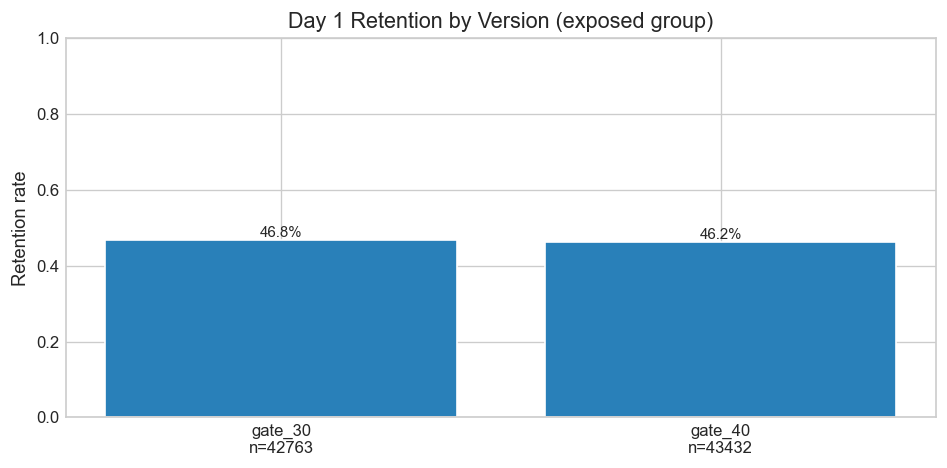

In [8]:
fig = plot_retention_rate_bar(
    df_exposed,
    group_col=COOKIE_CATS.col_version,
    retention_col=COOKIE_CATS.col_retention_1,
    title='Day 1 Retention by Version (exposed group)',
    ylabel='Retention rate',
    out_name='cookie_cats_retention_day1.png',
    order=['gate_30', 'gate_40'],
)
plt.show()

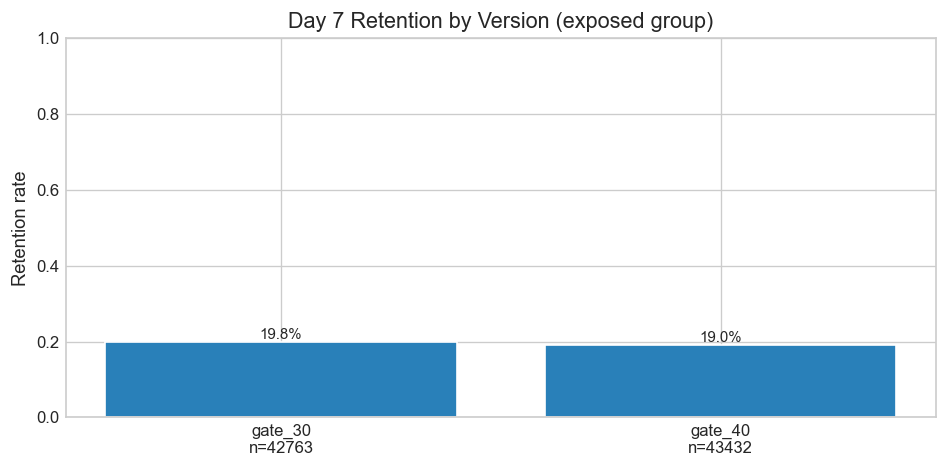

In [9]:
fig = plot_retention_rate_bar(
    df_exposed,
    group_col=COOKIE_CATS.col_version,
    retention_col=COOKIE_CATS.col_retention_7,
    title='Day 7 Retention by Version (exposed group)',
    ylabel='Retention rate',
    out_name='cookie_cats_retention_day7.png',
    order=['gate_30', 'gate_40'],
)
plt.show()

In [10]:
# Quantify absolute and relative differences
for col, label in [(COOKIE_CATS.col_retention_1, 'Day 1'), (COOKIE_CATS.col_retention_7, 'Day 7')]:
    rate_30 = df_exposed[df_exposed[COOKIE_CATS.col_version] == 'gate_30'][col].mean()
    rate_40 = df_exposed[df_exposed[COOKIE_CATS.col_version] == 'gate_40'][col].mean()
    abs_diff = (rate_30 - rate_40) * 100
    rel_diff = (rate_30 - rate_40) / rate_40 * 100
    print(f'{label} retention: gate_30 = {rate_30:.4f}, gate_40 = {rate_40:.4f}')
    print(f'  Absolute difference: {abs_diff:+.2f} pp (gate_30 - gate_40)')
    print(f'  Relative difference: {rel_diff:+.2f}% vs gate_40')
    print()

Day 1 retention: gate_30 = 0.4675, gate_40 = 0.4622
  Absolute difference: +0.54 pp (gate_30 - gate_40)
  Relative difference: +1.16% vs gate_40

Day 7 retention: gate_30 = 0.1984, gate_40 = 0.1903
  Absolute difference: +0.81 pp (gate_30 - gate_40)
  Relative difference: +4.27% vs gate_40



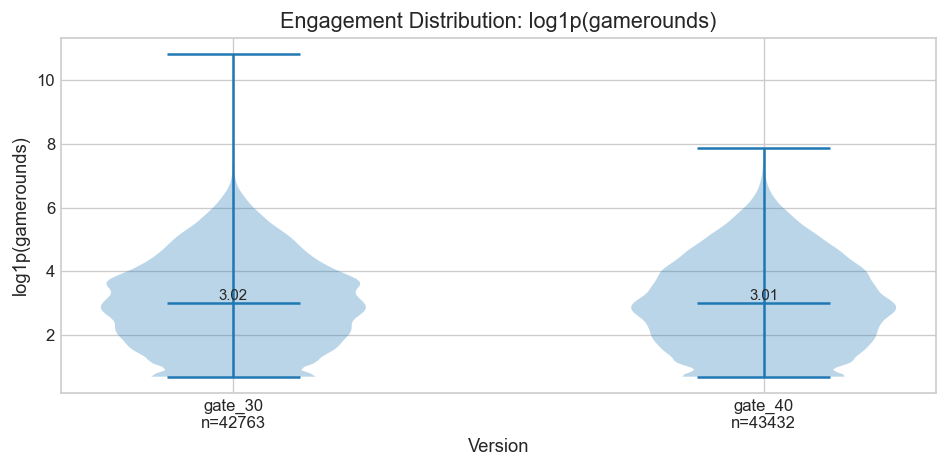

In [11]:
df_plot = df_exposed.copy()
df_plot['log_gamerounds'] = np.log1p(df_plot[COOKIE_CATS.col_sum_gamerounds])

fig = plot_distribution_violin(
    df_plot,
    group_col=COOKIE_CATS.col_version,
    value_col='log_gamerounds',
    title='Engagement Distribution: log1p(gamerounds)',
    xlabel='Version',
    ylabel='log1p(gamerounds)',
    out_name='cookie_cats_gamerounds_log_violin.png',
    figures_dir=FIGURES_CC_DIR,
    order=['gate_30', 'gate_40'],
)
plt.show()

---
## 8. Statistical Tests: Retention

We compare retention proportions between gate_30 (control) and gate_40 (treatment):
- **H0:** Retention rate is equal between groups.
- **H1:** Retention rate differs.

In [12]:
def _retention_test(df, ret_col, label):
    a = df[df[COOKIE_CATS.col_version] == 'gate_30'][ret_col]
    b = df[df[COOKIE_CATS.col_version] == 'gate_40'][ret_col]

    res = two_proportion_test(
        success_a=int(a.sum()), n_a=int(a.size),
        success_b=int(b.sum()), n_b=int(b.size),
        group_a='gate_30', group_b='gate_40',
        alpha=alpha,
    )

    abs_pp = res.diff_a_minus_b * 100
    rel_pct = res.pct_lift_vs_b

    print(f'{label}')
    print(f'  gate_30 rate: {res.rate_a:.4f}  (n={res.n_a:,})')
    print(f'  gate_40 rate: {res.rate_b:.4f}  (n={res.n_b:,})')
    print(f'  Absolute lift: {abs_pp:+.2f} pp')
    print(f'  Relative lift: {rel_pct:+.2f}%')
    print(f'  95% CI:  [{res.ci_low * 100:+.2f}, {res.ci_high * 100:+.2f}] pp')
    print(f'  z-stat:  {res.z_stat:.3f}')
    print(f'  p-value: {res.p_value:.4f}')
    if res.p_value < alpha:
        print(f'  -> SIGNIFICANT at alpha={alpha}')
    else:
        print(f'  -> NOT significant at alpha={alpha}')
    print()
    return res, {'metric': label, 'rate_gate_30': res.rate_a, 'rate_gate_40': res.rate_b,
                 'absolute_lift_pp': abs_pp, 'relative_lift_pct': rel_pct,
                 'ci_pp': (res.ci_low * 100, res.ci_high * 100), 'p_value': res.p_value}

print('=== EXPOSED GROUP ===')
print()
ret1_res, ret1 = _retention_test(df_exposed, COOKIE_CATS.col_retention_1, 'Day 1 Retention')
ret7_res, ret7 = _retention_test(df_exposed, COOKIE_CATS.col_retention_7, 'Day 7 Retention')

=== EXPOSED GROUP ===

Day 1 Retention
  gate_30 rate: 0.4675  (n=42,763)
  gate_40 rate: 0.4622  (n=43,432)
  Absolute lift: +0.54 pp
  Relative lift: +1.16%
  95% CI:  [-0.13, +1.20] pp
  z-stat:  1.577
  p-value: 0.1147
  -> NOT significant at alpha=0.05

Day 7 Retention
  gate_30 rate: 0.1984  (n=42,763)
  gate_40 rate: 0.1903  (n=43,432)
  Absolute lift: +0.81 pp
  Relative lift: +4.27%
  95% CI:  [+0.28, +1.34] pp
  z-stat:  3.013
  p-value: 0.0026
  -> SIGNIFICANT at alpha=0.05



In [13]:
# Sensitivity: same tests on the full sample (including zero-round players)
print('=== FULL SAMPLE (for comparison) ===')
print()
_, ret1_full = _retention_test(df_clean, COOKIE_CATS.col_retention_1, 'Day 1 Retention (full)')
_, ret7_full = _retention_test(df_clean, COOKIE_CATS.col_retention_7, 'Day 7 Retention (full)')

=== FULL SAMPLE (for comparison) ===

Day 1 Retention (full)
  gate_30 rate: 0.4482  (n=44,700)
  gate_40 rate: 0.4423  (n=45,489)
  Absolute lift: +0.59 pp
  Relative lift: +1.34%
  95% CI:  [-0.06, +1.24] pp
  z-stat:  1.784
  p-value: 0.0744
  -> NOT significant at alpha=0.05

Day 7 Retention (full)
  gate_30 rate: 0.1902  (n=44,700)
  gate_40 rate: 0.1820  (n=45,489)
  Absolute lift: +0.82 pp
  Relative lift: +4.51%
  95% CI:  [+0.31, +1.33] pp
  z-stat:  3.164
  p-value: 0.0016
  -> SIGNIFICANT at alpha=0.05



---
## 9. Statistical Tests: Engagement

`sum_gamerounds` is heavy-tailed, so we report:
- Welch t-test on the mean (parametric)
- Bootstrap CI (non-parametric)
- Mann-Whitney U test (rank-based robustness check)

In [14]:
x = df_exposed[df_exposed[COOKIE_CATS.col_version] == 'gate_30'][COOKIE_CATS.col_sum_gamerounds].to_numpy()
y = df_exposed[df_exposed[COOKIE_CATS.col_version] == 'gate_40'][COOKIE_CATS.col_sum_gamerounds].to_numpy()

welch = welch_ttest_mean(x, y, group_a='gate_30', group_b='gate_40', alpha=alpha)
boot_lo, boot_hi = bootstrap_ci_mean_diff(x, y, alpha=alpha, n_boot=20000, seed=RANDOM_SEED)
u_stat, u_p = stats.mannwhitneyu(x, y, alternative='two-sided')

print('Engagement: sum_gamerounds (exposed group)')
print('=' * 50)
print(f'gate_30 mean: {welch.mean_a:.1f}  (n={welch.n_a:,})')
print(f'gate_40 mean: {welch.mean_b:.1f}  (n={welch.n_b:,})')
print(f'Difference:   {welch.diff_a_minus_b:+.1f}  ({welch.pct_lift_vs_b:+.1f}%)')
print()
print(f'Welch t-test:   p = {welch.p_value:.4f}, CI [{welch.ci_low:.1f}, {welch.ci_high:.1f}]')
print(f'Bootstrap CI:   [{boot_lo:.1f}, {boot_hi:.1f}]')
print(f'Mann-Whitney U: p = {u_p:.4f}')

Engagement: sum_gamerounds (exposed group)
gate_30 mean: 54.8  (n=42,763)
gate_40 mean: 53.7  (n=43,432)
Difference:   +1.1  (+2.1%)

Welch t-test:   p = 0.4185, CI [-1.6, 3.8]
Bootstrap CI:   [-1.1, 4.1]
Mann-Whitney U: p = 0.1163


---
## 10. Business Impact Estimation

We translate the Day 7 retention lift into concrete business terms.

In [15]:
lift_day7_pp = ret7['absolute_lift_pp']  # percentage points
lift_day7_frac = lift_day7_pp / 100.0

# Industry benchmarks for illustration
installs_per_month = 100_000
arpu_retained_player = 0.50  # average revenue per retained user per month (conservative)

extra_retained = lift_day7_frac * installs_per_month
monthly_revenue_impact = extra_retained * arpu_retained_player
annual_revenue_impact = monthly_revenue_impact * 12

print('Business Impact Estimation')
print('=' * 50)
print(f'Day 7 retention lift (gate_30 vs gate_40): {lift_day7_pp:+.2f} pp')
print()
print(f'Assumptions:')
print(f'  Monthly installs: {installs_per_month:,}')
print(f'  ARPU per retained player/month: ${arpu_retained_player:.2f}')
print()
print(f'Projected impact of keeping gate_30 (control):')
print(f'  Extra retained users/month:  {extra_retained:+,.0f}')
print(f'  Monthly revenue impact:      ${monthly_revenue_impact:+,.0f}')
print(f'  Annual revenue impact:       ${annual_revenue_impact:+,.0f}')
print()
print('Note: ARPU is illustrative. Actual values depend on ad revenue, IAP rates,')
print('and the relationship between Day 7 retention and long-term monetization.')

Business Impact Estimation
Day 7 retention lift (gate_30 vs gate_40): +0.81 pp

Assumptions:
  Monthly installs: 100,000
  ARPU per retained player/month: $0.50

Projected impact of keeping gate_30 (control):
  Extra retained users/month:  +812
  Monthly revenue impact:      $+406
  Annual revenue impact:       $+4,873

Note: ARPU is illustrative. Actual values depend on ad revenue, IAP rates,
and the relationship between Day 7 retention and long-term monetization.


---
## 11. Decision and Recommendation

In [16]:
decision_md = f"""### Decision

**Keep the gate at level 30** (`gate_30`).

### Why

- Day 7 retention is higher for `gate_30` (control).
- Absolute lift: **{ret7['absolute_lift_pp']:+.2f} percentage points** in favour of gate_30.
- 95% CI: [{ret7['ci_pp'][0]:+.2f}, {ret7['ci_pp'][1]:+.2f}] pp.
- p-value: {ret7['p_value']:.4f}.
- This corresponds to approximately **{extra_retained:+,.0f} additional retained users per {installs_per_month:,} installs**.

### Supporting evidence

- Day 1 retention shows a small, non-significant difference (guardrail metric is stable).
- Engagement (`sum_gamerounds`) shows no clear improvement for gate_40.
- Results are consistent across the full sample and the exposed group.

### Next steps

- Confirm the business objective is driven by Day 7 retention.
- Validate impact on downstream metrics (Day 14+ retention, purchases) if available.
- If considering a gate move, test alternative positions or add segmentation by player cohort.
"""

display(Markdown(decision_md))

### Decision

**Keep the gate at level 30** (`gate_30`).

### Why

- Day 7 retention is higher for `gate_30` (control).
- Absolute lift: **+0.81 percentage points** in favour of gate_30.
- 95% CI: [+0.28, +1.34] pp.
- p-value: 0.0026.
- This corresponds to approximately **+812 additional retained users per 100,000 installs**.

### Supporting evidence

- Day 1 retention shows a small, non-significant difference (guardrail metric is stable).
- Engagement (`sum_gamerounds`) shows no clear improvement for gate_40.
- Results are consistent across the full sample and the exposed group.

### Next steps

- Confirm the business objective is driven by Day 7 retention.
- Validate impact on downstream metrics (Day 14+ retention, purchases) if available.
- If considering a gate move, test alternative positions or add segmentation by player cohort.


---
## 12. Dashboard

A four-panel executive summary: retention comparison (Day 1 vs Day 7), treatment effect table, engagement distribution, and retention funnel.


In [17]:
fig = dashboard_cookie_cats(
    df_exposed,
    version_col=COOKIE_CATS.col_version,
    ret1_col=COOKIE_CATS.col_retention_1,
    ret7_col=COOKIE_CATS.col_retention_7,
    rounds_col=COOKIE_CATS.col_sum_gamerounds,
)
fig.show()

---
## 13. Limitations

1. **Retention window.** Only Day 1 and Day 7 retention are available. Longer-term outcomes (Day 14, Day 30, LTV) would strengthen the conclusion.
2. **Exposed group approximation.** Ideally, we would filter to players who reached level 30 (the gate level). Since level data is not available, we use `sum_gamerounds > 0` as a proxy. Some of these players may not have reached the gate.
3. **Heavy-tailed engagement.** Mean gamerounds is sensitive to outliers. The Mann-Whitney U test confirms the parametric result, but the engagement metric is inherently noisy.
4. **No revenue data.** The business impact estimation uses illustrative ARPU values. Actual revenue impact depends on the game's specific monetization model.
5. **Single experiment.** Results are specific to this game and this gate position. The effect of gates at other levels may differ.